In [1]:
import os, cv2, json, glob, gc
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision.ops import nms
from sklearn.model_selection import train_test_split

from Network.index import ModelNetwork
from Augmentation.index import Augmentation
from utils.index import *
from utils.Plotter.index import Plotter

In [2]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

gc.collect()
print(torch.__version__)              # versao do PyTorch
print(torch.cuda.is_available())      # True se detectou a GPU
print(torch.cuda.get_device_name(0))  # nome da GPU

2.7.1+cu118
True
NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [3]:
models = [f'model_{i}' for i in sorted([int(path.split('_')[-1]) for path in os.listdir('Backup') if path.startswith('model_')])]
models

['model_1', 'model_2', 'model_3', 'model_4', 'model_5']

In [4]:
def modelScore(name):
    try:
        return json.load(open(f'Backup/{name}/info.json'))['trainer']['test_iou']
    except (OSError, KeyError, ValueError):
        return float('-inf')


modelId = max(models, key=modelScore)   # melhor modelo (maior IoU de teste)
baseDir = f'Backup/{modelId}'
print(baseDir, '- IoU %.3f' % modelScore(modelId))

Backup/model_3 - IoU 0.927


In [5]:
with open(f'{baseDir}/info.json', 'r', encoding='utf-8') as file:
    modelInfo = json.load(file)

modelOptions = modelInfo.get('model', {})
classes = modelInfo.get('classes', {})
names   = {value: label for label, value in classes.items()}
print(json.dumps(modelOptions, indent=4))

network   = ModelNetwork(**modelOptions)
modelData = torch.load(f'{baseDir}/model.pth', map_location=network.device)

network.model.load_state_dict(modelData['model'])
network.model.eval()
print(f'pesos de {modelId} carregados')

{
    "network": "fasterrcnn",
    "img_size": 512,
    "classes": 4,
    "channels": 3,
    "lr": 0.0001,
    "score_threshold": 0.5
}
pesos de model_3 carregados


# PREDIÇÕES

In [ ]:
IMG_SIZE        = modelOptions['img_size']
SCORE_THRESHOLD = modelOptions['score_threshold']
NMS_THRESHOLD   = modelInfo['processing'].get('nms_threshold', 0.3)
TEST_SIZE       = modelInfo['processing'].get('test_size', 0.10)

In [ ]:
df = pd.read_csv('../Dataset/DataBase.csv')
df['path']  = [os.path.join('../Dataset', path) for path in df.path]
df['value'] = df.label.map(classes)
df

,path,label,x_min,y_min,x_max,y_max,value
0,../Dataset/Aquisition/files/green/Screenshot f...,green,160,173,369,576,1
1,../Dataset/Aquisition/files/green/Screenshot f...,green,184,239,382,633,1
2,../Dataset/Aquisition/files/green/Screenshot f...,green,126,161,324,553,1
3,../Dataset/Aquisition/files/green/Screenshot f...,green,183,195,380,581,1
4,../Dataset/Aquisition/files/green/Screenshot f...,green,192,241,387,628,1
...,...,...,...,...,...,...,...
79,../Dataset/Aquisition/files/yellow/Screenshot ...,yellow,168,236,367,611,3
80,../Dataset/Aquisition/files/yellow/Screenshot ...,yellow,704,161,894,541,3
81,../Dataset/Aquisition/files/yellow/Screenshot ...,yellow,835,276,1039,646,3
82,../Dataset/Aquisition/files/yellow/Screenshot ...,yellow,406,171,590,554,3


In [ ]:
aux, df = train_test_split(df, test_size=TEST_SIZE, random_state=42, stratify=df.label)
df = df.reset_index(drop=True)
print(f'amostras de teste: {len(df)}')


class PredictDataset(Dataset):
    def __init__(self, df, img_size):
        self.df    = df.reset_index(drop=True)
        self.paths = self.df.path.unique()
        self.aug   = Augmentation(img_size)

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        path   = self.paths[index]
        rows   = self.df[self.df.path == path]
        image  = loadImage(path).astype(np.float32) / 255.0
        boxes  = rows[['x_min', 'y_min', 'x_max', 'y_max']].values
        labels = rows['value'].values.astype(np.int64)

        sample = self.aug(image=image, bboxes=boxes, labels=labels)
        boxes  = torch.as_tensor(np.array(sample['bboxes']), dtype=torch.float32).reshape(-1, 4)
        labels = torch.as_tensor(np.array(sample['labels']), dtype=torch.int64).reshape(-1)
        return (sample['image'], {'boxes': boxes, 'labels': labels}, path)


collate = lambda batch: tuple(zip(*batch))
predictDataset = PredictDataset(df, IMG_SIZE)
predictLoader  = DataLoader(predictDataset, batch_size=4, shuffle=False, num_workers=2, collate_fn=collate, pin_memory=torch.cuda.is_available())

amostras de teste: 9


Computing IoU: 100%|██████████| 3/3 [00:01<00:00,  2.37it/s]


model_3 -> IoU médio 0.928


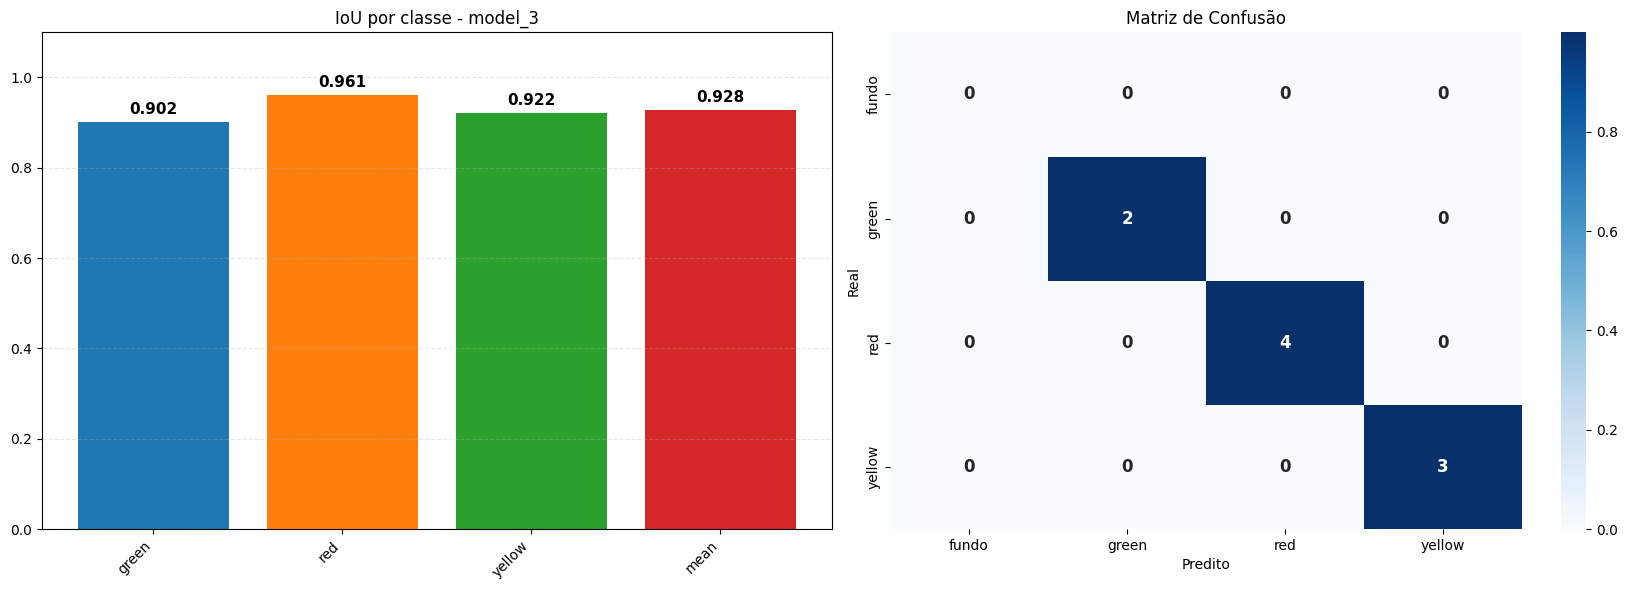

In [7]:
def computeIou(network, loader):
    network.model.eval()
    network.iou.reset()
    network.matrix.reset()

    with torch.no_grad():
        for imgs, targets, paths in tqdm(loader, desc='Computing IoU'):
            imgs    = [img.to(network.device) for img in imgs]
            targets = [{key: val.to(network.device) for key, val in tgt.items()} for tgt in targets]
            outputs = network.model(imgs)

            network.iou.update(outputs, targets)
            network.matrix.update(outputs, targets)

    return network.iou.compute()


mean_iou, class_ious = computeIou(network, predictLoader)
ious = {names[c]: val for c, val in class_ious.items()}
ious.update({'mean': mean_iou})
print('%s -> IoU médio %.3f' % (modelId, mean_iou))

plt.figure(figsize=(17, 6))
plt.subplot(1, 2, 1)
Plotter(ious, title=f'IoU por classe - {modelId}')
plt.subplot(1, 2, 2)
network.matrix.plot(names=['fundo'] + [names[c] for c in sorted(names)])
plt.tight_layout()
plt.show()

predições salvas em Backup/model_3/predict


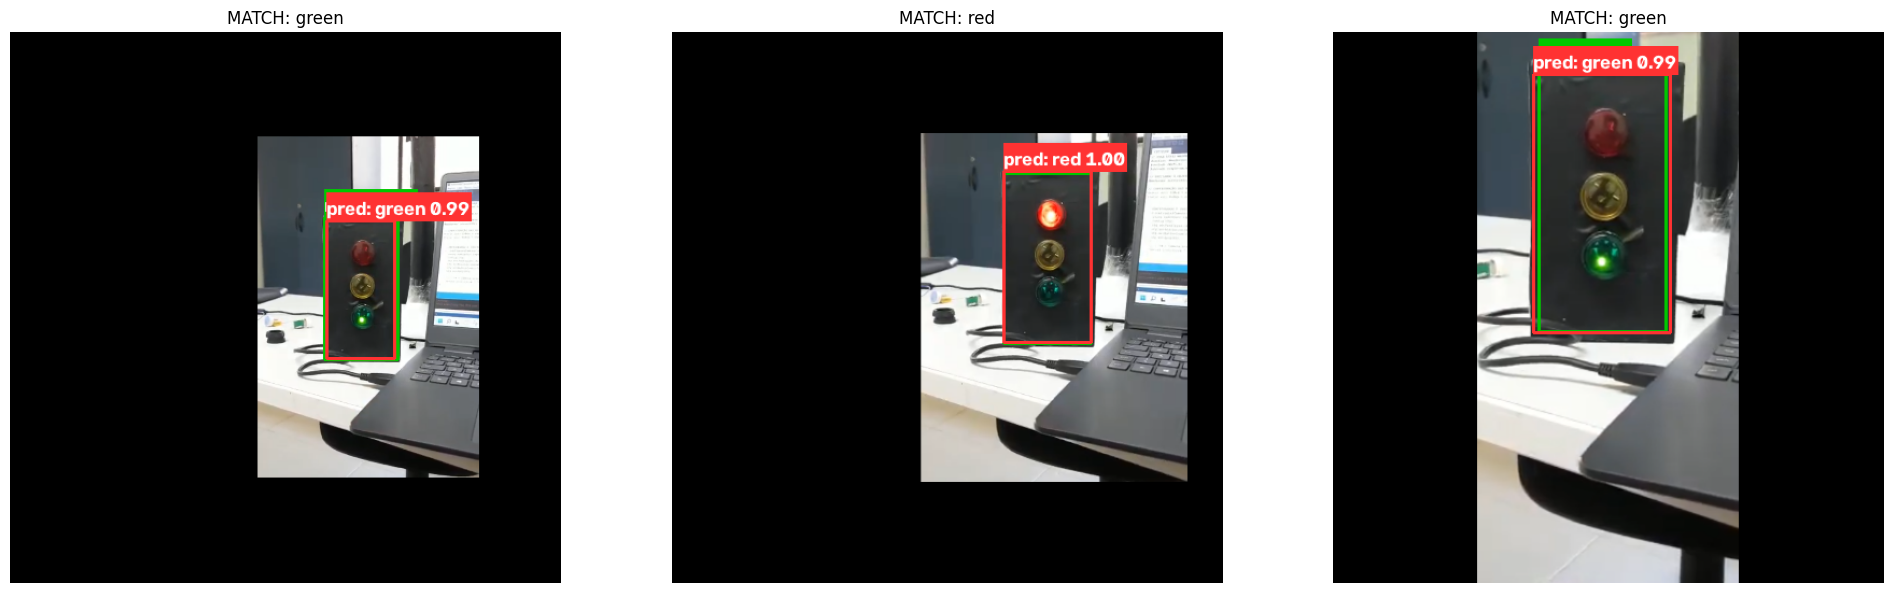

In [8]:
def plotPrediction(index, dataset=predictDataset, network=network, save=None):
    network.model.eval()
    image, target, path = dataset[index]

    with torch.no_grad():
        output = network.model([image.to(network.device)])[0]

    keep = nms(output['boxes'], output['scores'], NMS_THRESHOLD)
    boxes, scores, labels = output['boxes'][keep], output['scores'][keep], output['labels'][keep]
    mask = scores >= SCORE_THRESHOLD

    pred_boxes  = boxes[mask].cpu().numpy()
    pred_scores = scores[mask].tolist()
    pred_labels = [names[value] for value in labels[mask].tolist()]
    gt_boxes    = target['boxes'].cpu().numpy()
    gt_labels   = [names[value] for value in target['labels'].tolist()]

    img = np.ascontiguousarray(image.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
    for box, label in zip(gt_boxes, gt_labels):
        drawBox(img, box, f'real: {label}', (0, 200, 0))

    for box, label, score in zip(pred_boxes, pred_labels, pred_scores):
        drawBox(img, box, f'pred: {label} {score:.2f}', (255, 50, 50))

    match = sorted(gt_labels) == sorted(pred_labels)
    plt.imshow(img)
    plt.title(f'MATCH: {", ".join(pred_labels)}' if match else f'DIVERGENTE: real {gt_labels} pred {pred_labels}')
    plt.axis('off')

    if save:
        os.makedirs(os.path.dirname(save), exist_ok=True)
        plt.savefig(save, dpi=130, bbox_inches='tight')
        return plt.close()


outDir = f'{baseDir}/predict'
for i in range(min(len(predictDataset), 9)):
    plotPrediction(index=i, save=f'{outDir}/pred_{i + 1}.png')

plt.figure(figsize=(20, 6))
for k in range(min(3, len(predictDataset))):
    plt.subplot(1, 3, k + 1)
    plotPrediction(index=k)

plt.tight_layout()
print('predições salvas em', outDir)